# Exploratory Data Analysis

The objective of this notebook is to explore the cleaned movie dataset and investigate how movie runtime relates to other variables such as release year, genres, ratings, popularity, and revenue.

Before performing the analysis, the runtime column will be validated to ensure that only reliable observations are included.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

## Load Clean Dataset

In [2]:
data = pd.read_csv('../data/interim.csv', low_memory=False)

## Dataset Overview

In [3]:
data.shape

(44977, 20)

In [4]:
data.head()

,budget,id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,collection,genre_names,company_names,country_names,language_names,release_year,release_decade
0,30000000.0,862.0,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,1995-10-30,373554033.0,81.0,Toy Story,7.7,5415.0,['Toy Story Collection'],"['Animation', 'Comedy', 'Family']",['Pixar Animation Studios'],['United States of America'],['English'],1995.0,1990.0
1,65000000.0,8844.0,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,1995-12-15,262797249.0,104.0,Jumanji,6.9,2413.0,NaN,"['Adventure', 'Fantasy', 'Family']","['TriStar Pictures', 'Teitler Film', 'Intersco...",['United States of America'],"['English', 'Français']",1995.0,1990.0
2,NaN,15602.0,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,1995-12-22,NaN,101.0,Grumpier Old Men,6.5,92.0,['Grumpy Old Men Collection'],"['Romance', 'Comedy']","['Warner Bros.', 'Lancaster Gate']",['United States of America'],['English'],1995.0,1990.0
3,16000000.0,31357.0,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,1995-12-22,81452156.0,127.0,Waiting to Exhale,6.1,34.0,NaN,"['Comedy', 'Drama', 'Romance']",['Twentieth Century Fox Film Corporation'],['United States of America'],['English'],1995.0,1990.0
4,NaN,11862.0,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,1995-02-10,76578911.0,106.0,Father of the Bride Part II,5.7,173.0,['Father of the Bride Collection'],['Comedy'],"['Sandollar Productions', 'Touchstone Pictures']",['United States of America'],['English'],1995.0,1990.0


In [5]:
data.sample(5)

,budget,id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,collection,genre_names,company_names,country_names,language_names,release_year,release_decade
16866,NaN,23521.0,en,Daffy Duck's Quackbusters,In this feature-length film combining footage ...,0.870327,/kJOHa1wuKDX18tKhK6BL4dMkGHr.jpg,1988-09-24,NaN,72.0,Daffy Duck's Quackbusters,6.0,14.0,['Daffy Duck Movie Collection'],"['Fantasy', 'Science Fiction', 'Family']",['Warner Bros.'],['United States of America'],['English'],1988.0,1980.0
19059,300000.0,80468.0,en,Some Guy Who Kills People,A former mental patient's repressed anger reac...,3.064500,/bGSDCxEI0Y4tIcV9p5Eh5WCz1aL.jpg,2011-04-14,NaN,97.0,Some Guy Who Kills People,5.7,45.0,NaN,"['Comedy', 'Horror', 'Thriller']",NaN,['United States of America'],['English'],2011.0,2010.0
21665,NaN,99279.0,en,I am Fishead,A provocative snapshot of the world we live in...,0.042368,/6kseue7B5vEip9Ov5uYmfoz5bCW.jpg,2011-09-11,NaN,80.0,I am Fishead,4.0,1.0,NaN,['Documentary'],NaN,NaN,['English'],2011.0,2010.0
10109,NaN,26323.0,en,Bordertown,An ambitious Mexican-American gets mixed up wi...,1.588639,/sb368N5wa69aU0tbaE2i4Fvpd7V.jpg,1935-01-23,NaN,90.0,Bordertown,4.8,8.0,NaN,"['Crime', 'Drama']",['Warner Bros.'],['United States of America'],['English'],1935.0,1930.0
15235,NaN,35166.0,ro,Reconstituirea,"A prosecutor, policemen and teacher bring the ...",0.165803,/2JGT5LylTUVxnsYxt1eXqZle9RN.jpg,1968-01-05,NaN,100.0,The Reenactment,5.0,4.0,NaN,['Drama'],['Filmstudio Bucuresti'],['Romania'],['Română'],1968.0,1960.0


In [6]:
# Convert columns from string to list
import ast

columns_to_convert = ['collection', 'genre_names', 'company_names',
                       'country_names', 'language_names']

for col in columns_to_convert:
    data[col] = data[col].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x)

# Verify the result
# Create a DataFrame to Verify the result
col_verify = pd.DataFrame({
    'Column': columns_to_convert,
    'Sample Value':  [data[col].iloc[0] for col in columns_to_convert],
    'Sample_Dtype': [type(data[col].iloc[0]) for col in columns_to_convert],
})
col_verify

,Column,Sample Value,Sample_Dtype
0,collection,[Toy Story Collection],<class 'list'>
1,genre_names,"[Animation, Comedy, Family]",<class 'list'>
2,company_names,[Pixar Animation Studios],<class 'list'>
3,country_names,[United States of America],<class 'list'>
4,language_names,[English],<class 'list'>


## Runtime Validation

Before exploring runtime patterns, we first verify that the runtime column is reliable for analysis. This includes identifying missing values, suspicious runtimes, and extreme observations. Only after validating the data quality will we proceed with the exploratory analysis.

In [7]:
runtime = data['runtime']
runtime.describe()

count    43231.000000
mean        97.531794
std         34.711792
min          1.000000
25%         86.000000
50%         95.000000
75%        107.000000
max       1256.000000
Name: runtime, dtype: float64

In [8]:
print(runtime.isna().sum())
print(runtime.isna().mean() * 100)

1746
3.8819841252195566


In [9]:
runtime_data = data.dropna(subset=["runtime"]).copy()

In [10]:
runtime.sort_values().head(10)

44961    1.0
44931    1.0
25030    1.0
19885    1.0
44237    1.0
39579    1.0
36248    1.0
36247    1.0
28376    1.0
40793    1.0
Name: runtime, dtype: float64

In [11]:
runtime.dropna().sort_values().tail(10)

34364     840.0
34429     840.0
19042     874.0
26486     877.0
27649     900.0
13885     925.0
13701     931.0
40543    1140.0
19837    1140.0
24003    1256.0
Name: runtime, dtype: float64

In [12]:
data.loc[
    data["runtime"] <= 10,
    ["title", "runtime", "release_year", "genre_names"]
].sort_values("runtime")

,title,runtime,release_year,genre_names
44961,The One-Man Band,1.0,1900.0,"[Fantasy, Action, Thriller]"
16165,The Four Troublesome Heads,1.0,1898.0,"[Comedy, Fantasy]"
16170,The Human Pyramid,1.0,1899.0,[Fantasy]
17236,Meat Love,1.0,1989.0,"[Comedy, Drama, Fantasy]"
17469,Edison Kinetoscopic Record of a Sneeze,1.0,1894.0,[Documentary]
...,...,...,...,...
38510,Multiple SIDosis,10.0,1970.0,NaN
38525,There Will Come Soft Rains,10.0,1984.0,"[Animation, Science Fiction]"
44658,Polygon,10.0,1977.0,[Animation]
44727,Rick and Morty: State of Georgia Vs. Denver Fe...,10.0,2016.0,"[Comedy, Crime]"


In [13]:
data.nlargest(
    20,
    "runtime"
)[["title", "runtime", "release_year", "genre_names"]]

,title,runtime,release_year,genre_names
24003,Centennial,1256.0,1978.0,"[Drama, History]"
19837,Jazz,1140.0,2001.0,[Documentary]
40543,Baseball,1140.0,1994.0,[Documentary]
13701,Berlin Alexanderplatz,931.0,1980.0,[Drama]
13885,Heimat: A Chronicle of Germany,925.0,1984.0,"[Drama, History]"
27649,The Story of Film: An Odyssey,900.0,2011.0,[Documentary]
26486,Taken,877.0,2002.0,[Science Fiction]
19042,The War,874.0,2007.0,"[Documentary, History, War]"
34364,The Roosevelts: An Intimate History,840.0,2014.0,"[History, Documentary]"
34429,Seventeen Moments in Spring,840.0,1973.0,"[Adventure, Drama, History, War]"


## Runtime Distribution
### Histogram

Now that the runtime column has been validated, we explore its overall distribution to understand the typical movie length and identify any notable patterns.

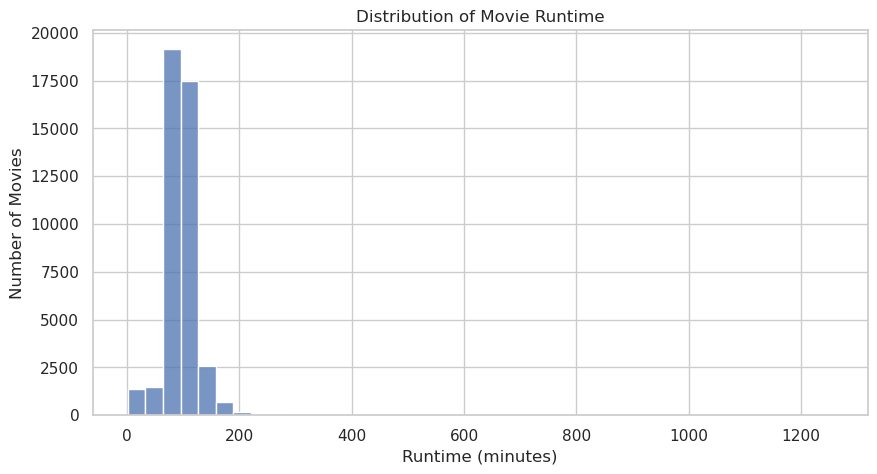

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(data=runtime_data, x="runtime", bins=40)

plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

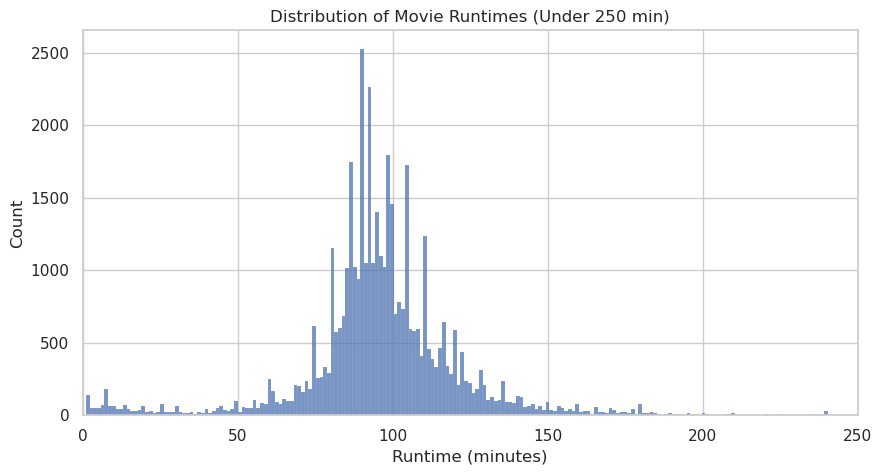

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=runtime_data,
    x="runtime",
    bins='auto'
)

plt.xlabel("Runtime (minutes)")
plt.title("Distribution of Movie Runtimes (Under 250 min)")
plt.xlim(0,250)

plt.show()

### Boxplot

A boxplot provides a compact summary of the runtime distribution and helps identify potential outliers.

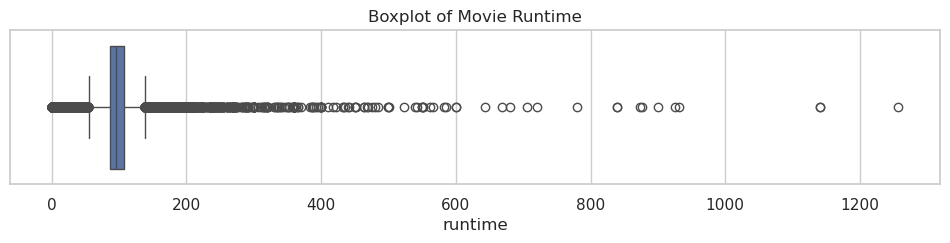

In [16]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=runtime_data,
    x="runtime"
)

plt.title("Boxplot of Movie Runtime")

plt.show()

In [17]:
# Count and mean of movies with runtime > 600
print('Count:', (data['runtime'] > 600).sum())
print('Mean:', data[data['runtime'] > 600]['runtime'].mean())

Count: 16
Mean: 870.0625


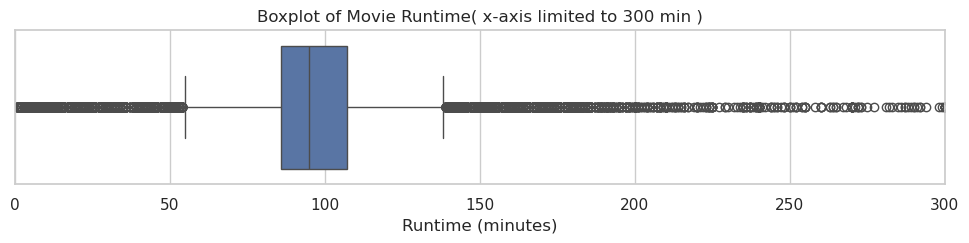

In [18]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=runtime_data,
    x="runtime"
)
plt.xlim(0,300)
plt.xlabel("Runtime (minutes)")
plt.title("Boxplot of Movie Runtime( x-axis limited to 300 min )")

plt.show()

### Histogram with Kernel Density Estimation (KDE)

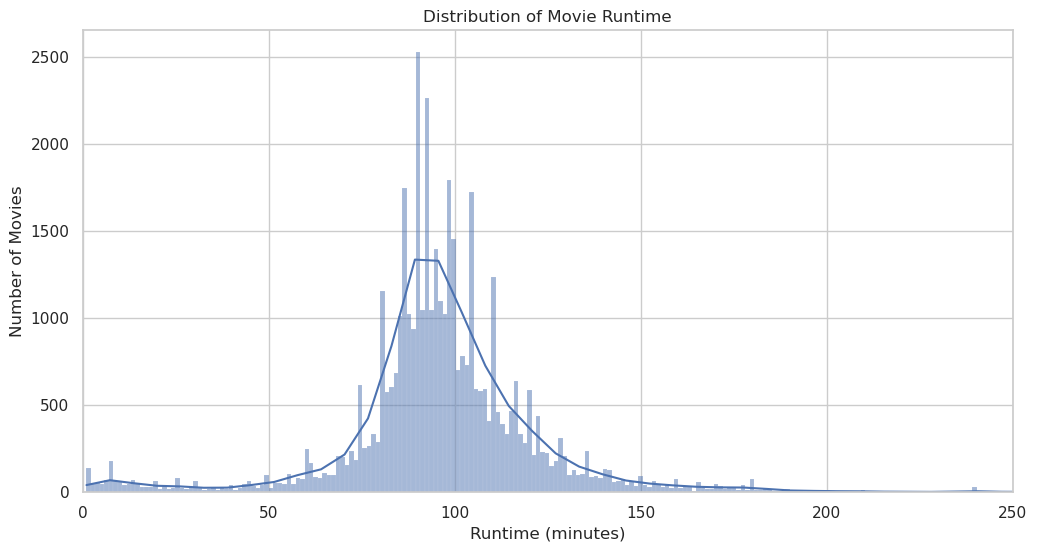

In [19]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=runtime_data,
    x="runtime",
    bins='auto',
    kde=True
)

plt.xlim(0, 250)

plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

The runtime distribution is unimodal, with a clear peak around 90–100 minutes. The distribution is right-skewed, indicating that while a small number of movies have exceptionally long runtimes, the vast majority fall between 80 and 120 minutes. This suggests that very long movies are rare and should be treated as exceptional cases rather than representative of the overall dataset.

### Runtime Threshold Analysis

In [20]:
threshold = [90, 120, 150, 180, 240]
summary = []

for t in threshold:
    summary.append({
        "Runtime > (min)" : t,
        "Movies" : (runtime_data['runtime'] > t).sum(),
        "Percentage" : (runtime_data['runtime'] > t).mean() * 100
    }) 

runtime_summary = pd.DataFrame(summary)
runtime_summary

,Runtime > (min),Movies,Percentage
0,90,26962,62.367283
1,120,4976,11.510259
2,150,1384,3.201406
3,180,517,1.195901
4,240,195,0.451065


Although nearly 60% of movies are longer than 90 minutes, only about 1.15% exceed three hours (180 minutes), indicating that extremely long movies are uncommon.

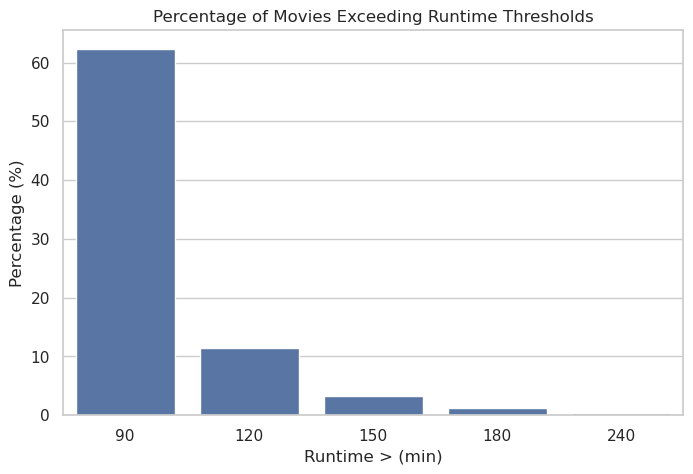

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=runtime_summary,
    x="Runtime > (min)",
    y="Percentage"
)

plt.title("Percentage of Movies Exceeding Runtime Thresholds")
plt.ylabel("Percentage (%)")

plt.show()

## Runtime Over Time
Has the average runtime of movies changed over time?

In [22]:
data["release_year"].describe()

count    44899.000000
mean      1991.819395
std         24.071299
min       1874.000000
25%       1978.000000
50%       2001.000000
75%       2010.000000
max       2017.000000
Name: release_year, dtype: float64

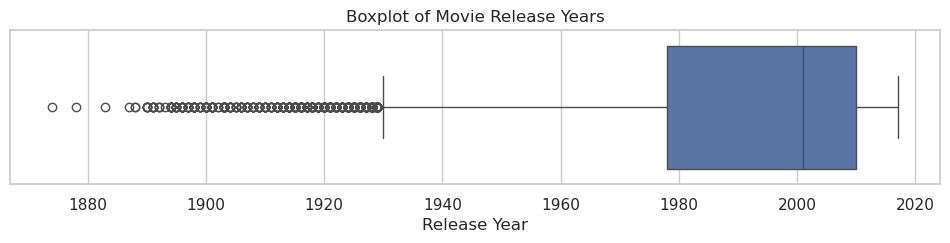

In [23]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=runtime_data,
    x="release_year"
)

plt.xlabel("Release Year")
plt.title("Boxplot of Movie Release Years")

plt.show()

In [24]:
data["release_year"].isnull().sum()

np.int64(78)

In [25]:
runtime_by_year = (
    runtime_data
    .groupby("release_year")["runtime"]
    .mean()
    .reset_index()
)

runtime_by_year.sample(10)

,release_year,runtime
44,1929.0,82.040541
37,1922.0,70.290323
103,1988.0,100.108168
129,2014.0,96.310920
69,1954.0,94.266304
131,2016.0,97.075447
56,1941.0,90.619048
54,1939.0,90.676692
82,1967.0,97.228571
59,1944.0,89.352113


In [26]:
movies_per_year = (
    runtime_data.groupby("release_year")
    .size()
    .reset_index(name="movie_count")
)

movies_per_year.sample(10)

,release_year,movie_count
38,1923.0,23
36,1921.0,33
98,1983.0,339
32,1917.0,17
130,2015.0,1767
125,2010.0,1397
117,2002.0,847
48,1933.0,145
59,1944.0,142
28,1913.0,13


In [27]:
valid_years = movies_per_year.loc[
    movies_per_year["movie_count"] >= 30,
    "release_year"
]

runtime_by_year_filtered = runtime_by_year[
    runtime_by_year["release_year"].isin(valid_years)
]

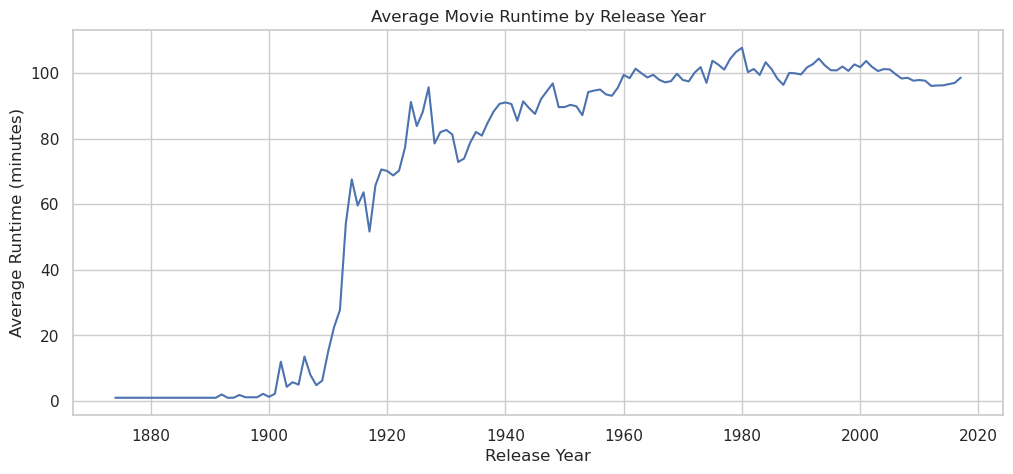

In [28]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=runtime_by_year,
    x="release_year",
    y="runtime"
)

plt.title("Average Movie Runtime by Release Year")
plt.ylabel("Average Runtime (minutes)")
plt.xlabel("Release Year")

plt.show()

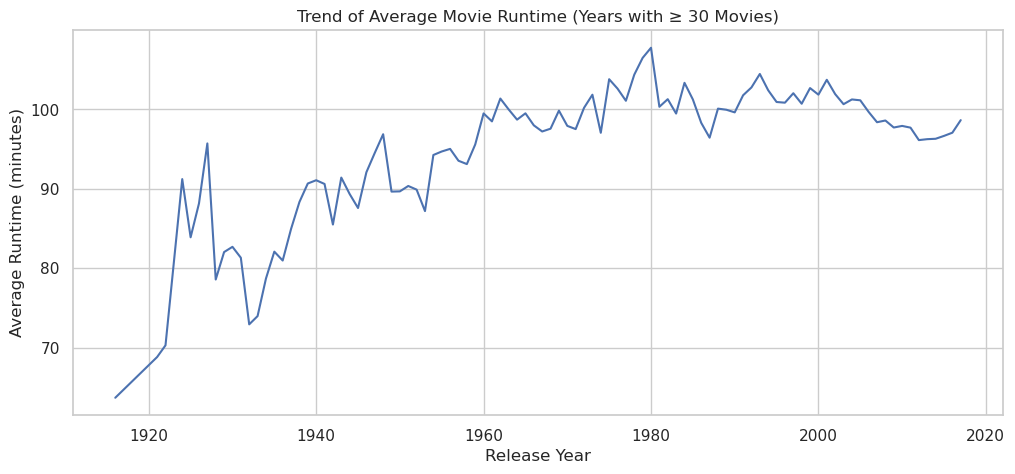

In [29]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=runtime_by_year_filtered,
    x="release_year",
    y="runtime"
)

plt.title("Trend of Average Movie Runtime (Years with ≥ 30 Movies)")
plt.ylabel("Average Runtime (minutes)")
plt.xlabel("Release Year")

plt.show()

## Runtime by Genre

To investigate whether movie runtime differs across genres, we compare the distribution and central tendency of runtime across movie genres.

In [30]:
genre_data = runtime_data[
    ["title", "runtime", "genre_names"]
].explode("genre_names")

genre_data.head()

,title,runtime,genre_names
0,Toy Story,81.0,Animation
0,Toy Story,81.0,Comedy
0,Toy Story,81.0,Family
1,Jumanji,104.0,Adventure
1,Jumanji,104.0,Fantasy


Since a movie can belong to multiple genres, the `genre_names` column contains lists of genres. We use `explode()` to create one row for each movie-genre relationship, allowing us to analyze runtime separately for each genre.

In [31]:
print(genre_data["genre_names"].isna().sum())
print(genre_data["genre_names"].isna().mean() * 100)

1869
2.0755597014925375


In [32]:
genre_data = genre_data.dropna(
    subset=["genre_names"]
).copy()

In [33]:
genre_data["genre_names"]

0        Animation
0           Comedy
0           Family
1        Adventure
1          Fantasy
           ...    
44972       Family
44973        Drama
44974       Action
44974        Drama
44974     Thriller
Name: genre_names, Length: 88179, dtype: object

In [34]:
genre_counts = genre_data["genre_names"].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

total_movies = genre_counts['Count'].sum()
genre_counts['Percentage'] = (genre_counts['Count'] / total_movies * 100).round(2)

genre_counts

,Genre,Count,Percentage
0,Drama,19633,22.26
1,Comedy,12578,14.26
2,Thriller,7415,8.41
3,Romance,6536,7.41
4,Action,6425,7.29
5,Horror,4558,5.17
6,Crime,4205,4.77
7,Documentary,3728,4.23
8,Adventure,3416,3.87
9,Science Fiction,2968,3.37


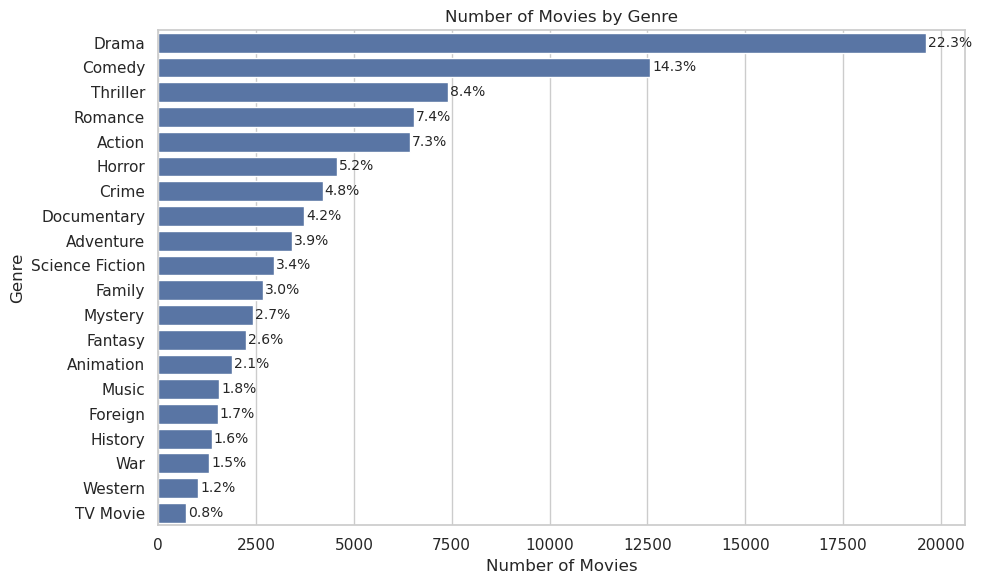

In [35]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=genre_counts,
    x='Count',
    y='Genre'
)

total = genre_counts['Count'].sum()
for i, row in genre_counts.iterrows():
    percent = (row['Count'] / total * 100).round(1)
    ax.text(row['Count'] + 50, i, f'{percent}%', va='center', fontsize=10)

plt.title("Number of Movies by Genre")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### Runtime Comparison Across Genres

Before comparing runtime across genres, we examine the number of observations available for each genre. This helps us assess whether the group-level runtime statistics are based on sufficiently large samples.

In [36]:
genre_runtime = (
    genre_data
    .groupby("genre_names")["runtime"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

genre_runtime

,count,mean,median
genre_names,,,
History,1368,126.285819,114.0
War,1299,114.026174,106.0
Drama,19633,105.138288,100.0
Romance,6536,104.336291,100.0
Foreign,1522,105.009855,99.0
Crime,4205,101.563615,99.0
Adventure,3416,103.067037,98.0
Action,6425,102.707393,98.0
Music,1557,100.862556,98.0


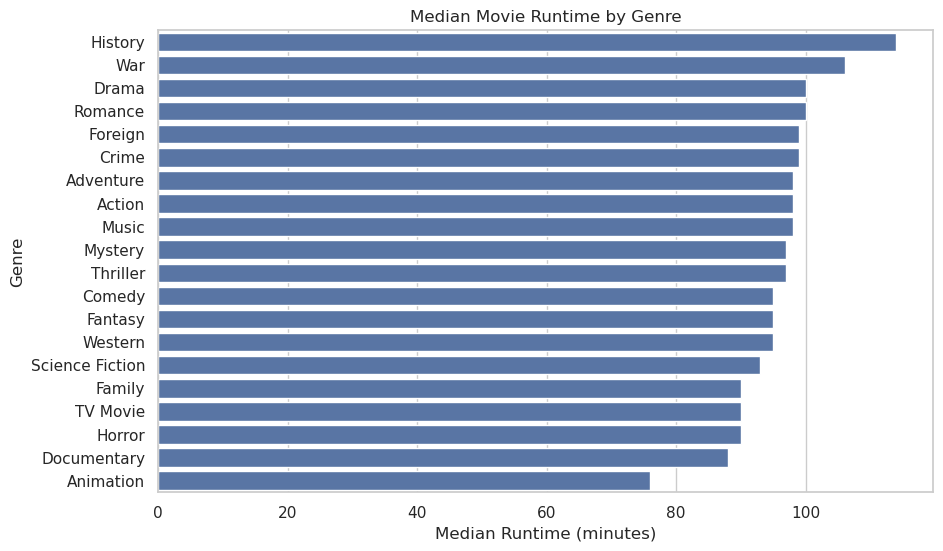

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_runtime,
    x="median",
    y=genre_runtime.index
)

plt.title("Median Movie Runtime by Genre")
plt.xlabel("Median Runtime (minutes)")
plt.ylabel("Genre")

plt.show()

### Runtime Distribution by Genre

Summary statistics such as the mean and median provide a useful overview of runtime across genres, but they do not show the full distribution within each genre. A boxplot allows us to compare the median, spread, and potential extreme values of runtime across genres.

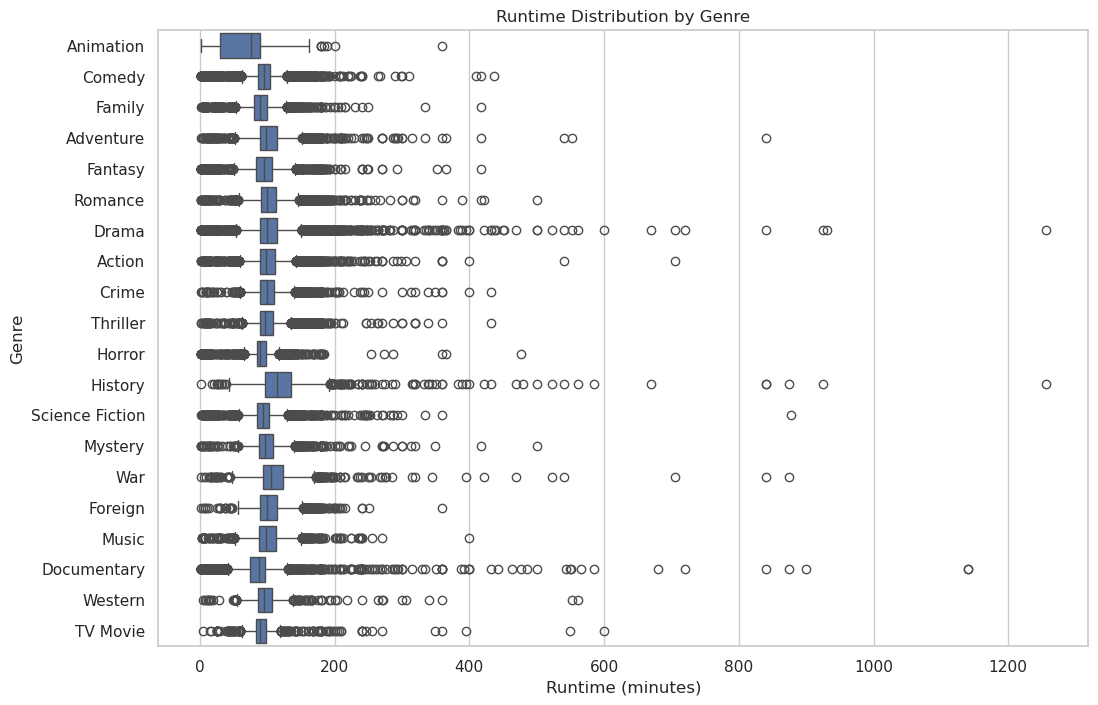

In [38]:
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=genre_data,
    x="runtime",
    y="genre_names"
)

plt.title("Runtime Distribution by Genre")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Genre")

plt.show()

In [39]:
genre_runtime.sort_values(
    "median",
    ascending=False
)

,count,mean,median
genre_names,,,
History,1368,126.285819,114.0
War,1299,114.026174,106.0
Drama,19633,105.138288,100.0
Romance,6536,104.336291,100.0
Foreign,1522,105.009855,99.0
Crime,4205,101.563615,99.0
Adventure,3416,103.067037,98.0
Action,6425,102.707393,98.0
Music,1557,100.862556,98.0


## Runtime and Rating

This section examines whether movie runtime is associated with audience ratings. Before comparing the two variables, the distribution and completeness of the rating variable are checked.

In [40]:
data["vote_average"].describe()

count    44977.000000
mean         5.624159
std          1.915806
min          0.000000
25%          5.000000
50%          6.000000
75%          6.800000
max         10.000000
Name: vote_average, dtype: float64

In [41]:
data["vote_average"].isna().sum()

np.int64(0)

In [42]:
data['vote_average'].value_counts()

vote_average
0.0    2928
6.0    2434
5.0    1977
7.0    1866
6.5    1707
       ... 
9.4       3
9.8       1
9.6       1
0.7       1
1.1       1
Name: count, Length: 92, dtype: int64

### Handling Zero Ratings

A small but important data-quality issue was identified in `vote_average`: 2,928 records have a rating of 0. Since a zero rating is not considered a meaningful audience rating for this analysis, these records are excluded from analyses involving `vote_average`. The original dataset is kept unchanged.

In [43]:
runtime_rating_data = data[
    ["title", "runtime", "vote_average"]
].dropna(
    subset=["runtime", "vote_average"]
).query("vote_average > 0").copy()

In [44]:
runtime_rating_data.shape

(40733, 3)

In [45]:
runtime_rating_data["vote_average"].min()

0.5

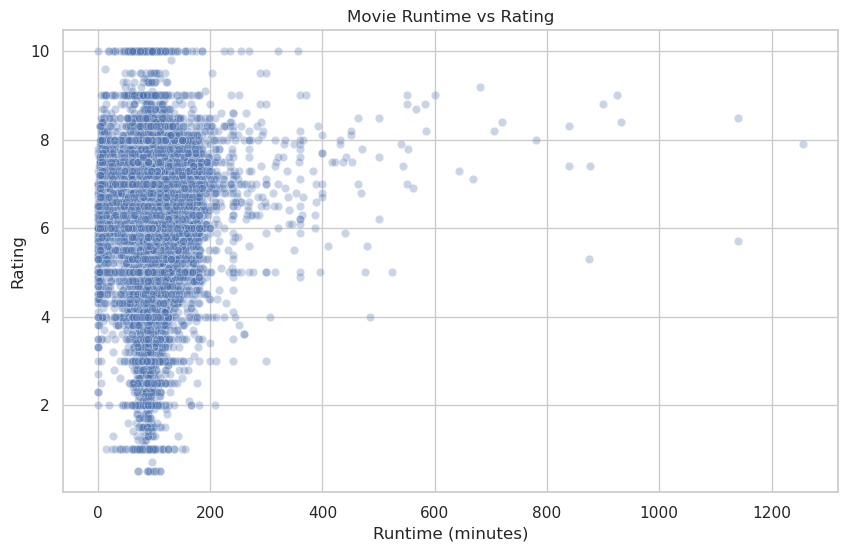

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=runtime_rating_data,
    x="runtime",
    y="vote_average",
    alpha=0.3
)

plt.title("Movie Runtime vs Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Rating")

plt.show()

In [47]:
runtime_rating_data[
    ["runtime", "vote_average"]
].corr()

,runtime,vote_average
runtime,1.000000,0.108405
vote_average,0.108405,1.000000


In [48]:
bins = [0, 60, 90, 120, 150, 180, float("inf")]

labels = [
    "<60",
    "60-89",
    "90-119",
    "120-149",
    "150-179",
    "180+"
]

runtime_rating_data["runtime_group"] = pd.cut(
    runtime_rating_data["runtime"],
    bins=bins,
    labels=labels,
    right=False
)

runtime_rating_data

,title,runtime,vote_average,runtime_group
0,Toy Story,81.0,7.7,60-89
1,Jumanji,104.0,6.9,90-119
2,Grumpier Old Men,101.0,6.5,90-119
3,Waiting to Exhale,127.0,6.1,120-149
4,Father of the Bride Part II,106.0,5.7,90-119
...,...,...,...,...
44970,Caged Heat 3000,85.0,3.5,60-89
44971,Robin Hood,104.0,5.7,90-119
44972,Subdue,90.0,4.0,90-119
44973,Century of Birthing,360.0,9.0,180+


In [49]:
runtime_group_counts = (
    runtime_rating_data["runtime_group"]
    .value_counts()
    .sort_index()
)

runtime_group_counts

runtime_group
<60         2051
60-89      10417
90-119     22891
120-149     3966
150-179      849
180+         559
Name: count, dtype: int64

In [50]:
rating_by_runtime_group = (
    runtime_rating_data
    .groupby("runtime_group", observed=True)["vote_average"]
    .agg(["count", "mean", "median"])
)

rating_by_runtime_group

,count,mean,median
runtime_group,,,
<60,2051,6.424671,6.5
60-89,10417,5.784372,5.9
90-119,22891,5.981408,6.0
120-149,3966,6.466843,6.6
150-179,849,6.534629,6.7
180+,559,6.828623,7.0


Longer movies, particularly those above 120 minutes, tend to have higher median ratings in this dataset, but the relationship is not consistently increasing across all runtime ranges.

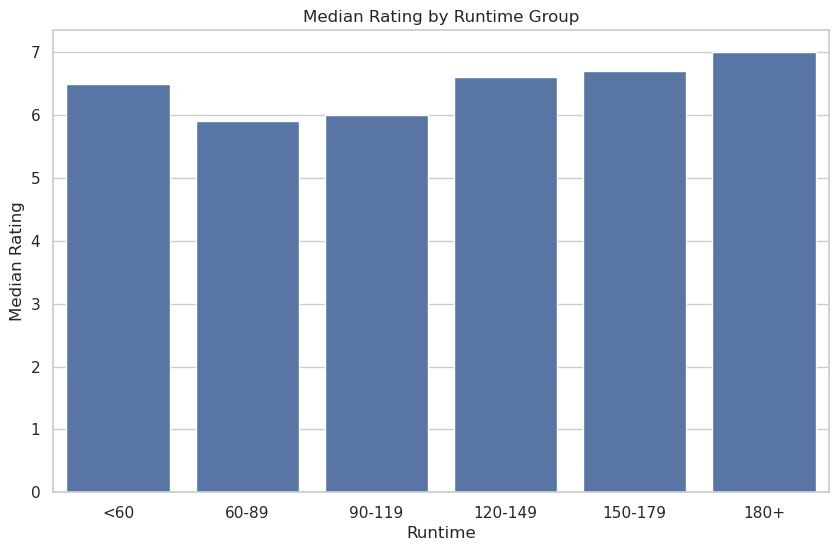

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rating_by_runtime_group.reset_index(),
    x="runtime_group",
    y="median"
)

plt.title("Median Rating by Runtime Group")
plt.xlabel("Runtime")
plt.ylabel("Median Rating")

plt.show()

### Rating Distribution Across Runtime Groups

Group-level mean and median ratings provide a summary of the relationship between runtime and rating. To examine the variation within each runtime group, the distribution of ratings is compared using boxplots.

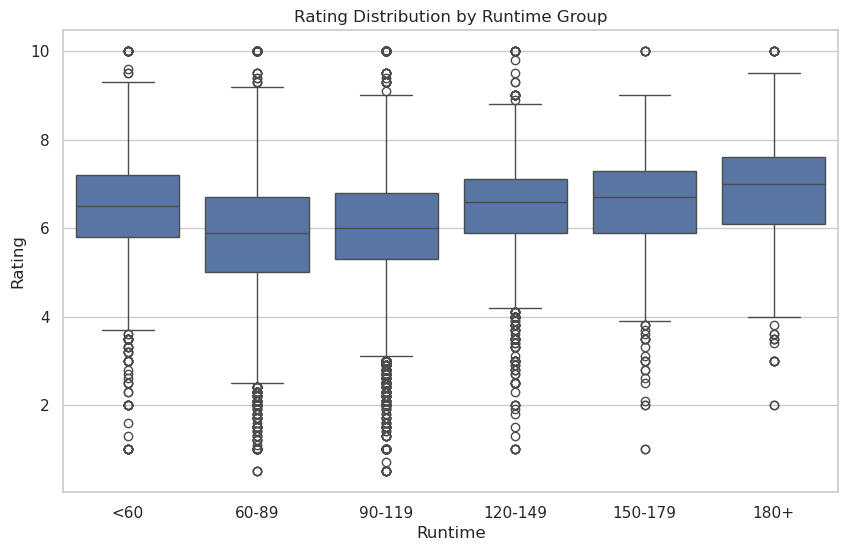

In [52]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=runtime_rating_data,
    x="runtime_group",
    y="vote_average"
)

plt.title("Rating Distribution by Runtime Group")
plt.xlabel("Runtime")
plt.ylabel("Rating")

plt.show()

### Findings

The correlation between runtime and rating is positive but weak (r = 0.108), indicating only a weak linear association between the two variables.

When movies are grouped by runtime, median ratings tend to be higher among movies longer than 120 minutes. However, the pattern is not consistently increasing across all runtime groups, as movies shorter than 60 minutes have a higher median rating than movies in the 60–89 minute group.

Therefore, runtime alone does not appear to be a strong predictor of movie rating, although longer movies in this dataset tend to have somewhat higher typical ratings.

## Runtime and Popularity

This section examines whether movie runtime is associated with popularity. Before comparing the two variables, the distribution and completeness of the popularity variable are examined.

In [53]:
data["popularity"].describe()

count    44977.000000
mean         2.939003
std          6.025152
min          0.000000
25%          0.390858
50%          1.135373
75%          3.729553
max        547.488298
Name: popularity, dtype: float64

In [54]:
data["popularity"].isna().sum()

np.int64(0)

In [55]:
data["popularity"].value_counts()

popularity
0.000000    64
0.000001    56
0.000308    42
0.000220    39
0.000578    37
            ..
1.215778     1
5.087320     1
0.128607     1
0.132201     1
0.704172     1
Name: count, Length: 43339, dtype: int64

### Popularity Distribution

The popularity variable is highly right-skewed. Most movies have relatively low popularity values, while a small number of movies have substantially higher values.

Extreme popularity values are retained because they were not identified as invalid during the data-cleaning stage. A logarithmic scale is used when visualizing popularity to make the distribution easier to examine.

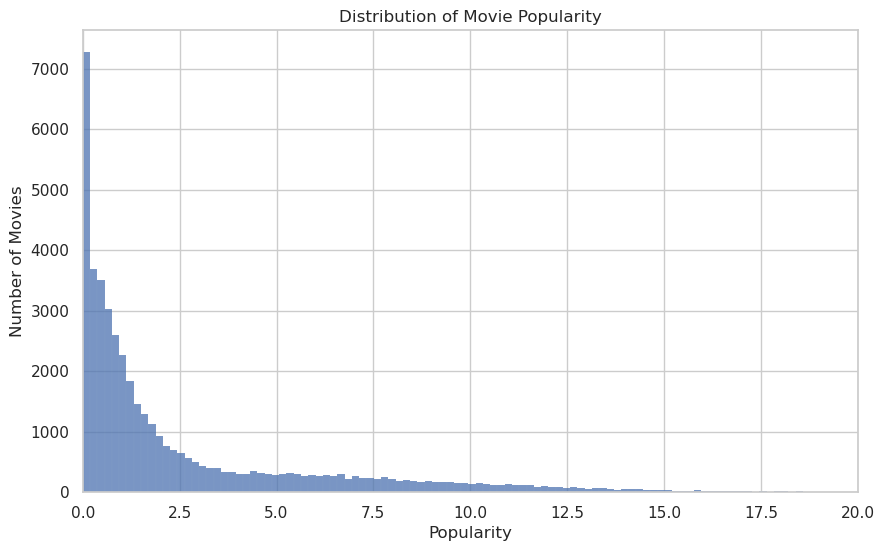

In [56]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="popularity",
    bins='auto'
)

plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")

plt.xlim(0, 20)
plt.show()

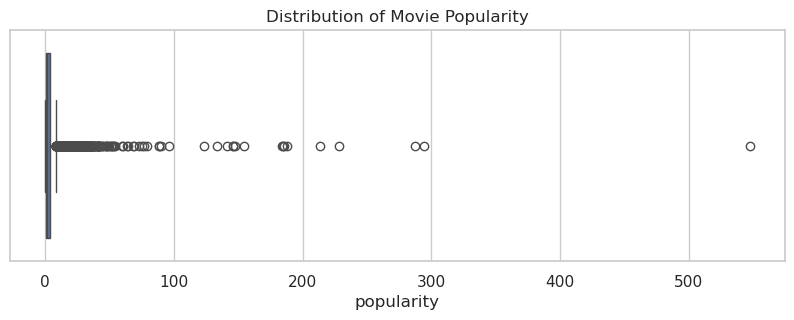

In [57]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=data,
    x="popularity"
)

plt.title("Distribution of Movie Popularity")

plt.show()

In [58]:
data["popularity"].skew()

np.float64(29.22385077042557)

`popularity` has a highly right-skewed distribution.

In [59]:
runtime_popularity_data = data[
    ["title", "runtime", "popularity"]
].dropna(
    subset=["runtime", "popularity"]
).copy()

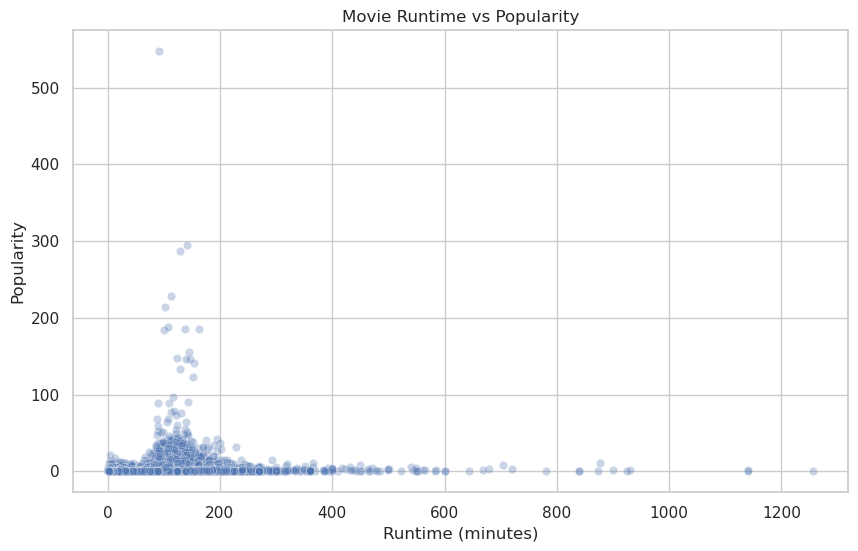

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=runtime_popularity_data,
    x="runtime",
    y="popularity",
    alpha=0.3
)

plt.title("Movie Runtime vs Popularity")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Popularity")

plt.show()

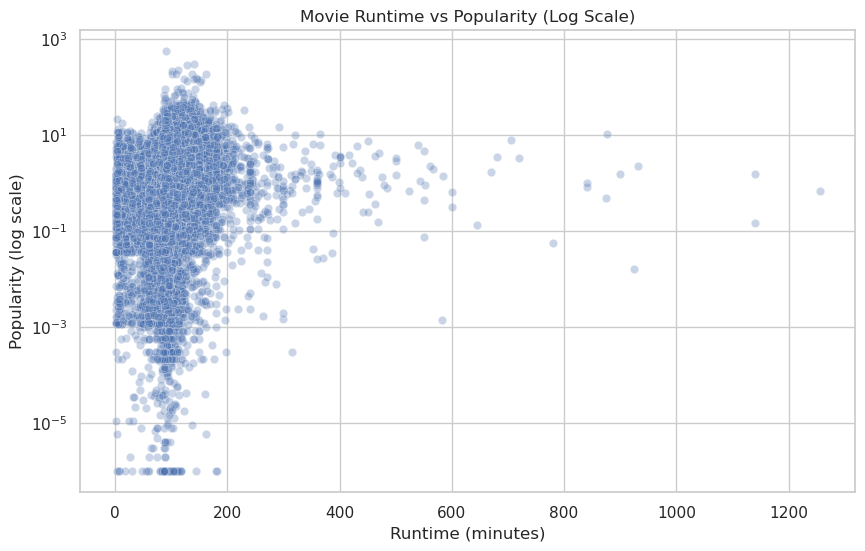

In [61]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=runtime_popularity_data,
    x="runtime",
    y="popularity",
    alpha=0.3
)

plt.yscale("log")

plt.title("Movie Runtime vs Popularity (Log Scale)")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Popularity (log scale)")

plt.show()

In [62]:
(runtime_popularity_data["popularity"] == 0).sum()

np.int64(40)

In [63]:
runtime_popularity_data[
    ["runtime", "popularity"]
].corr()

,runtime,popularity
runtime,1.000000,0.109874
popularity,0.109874,1.000000


In [64]:
runtime_popularity_spearman = (
    runtime_popularity_data["runtime"]
    .corr(
        runtime_popularity_data["popularity"],
        method="spearman"
    )
)

runtime_popularity_spearman

np.float64(0.2779346077887616)

### Runtime and Popularity Relationship

The Pearson correlation between runtime and popularity is 0.110, indicating a weak positive linear association.

The Spearman correlation is higher at 0.278, suggesting that the rank-based association between runtime and popularity is somewhat stronger than the linear association.

Overall, the relationship remains weak, so runtime alone does not appear to be a strong indicator of movie popularity.

## Runtime and Revenue

This section examines the relationship between movie runtime and revenue. Before analyzing the relationship, the completeness and distribution of the revenue variable are examined.

In [65]:
data["revenue"].describe()

count    7.385000e+03
mean     6.896865e+07
std      1.466090e+08
min      1.000000e+00
25%      2.405420e+06
50%      1.687267e+07
75%      6.764269e+07
max      2.787965e+09
Name: revenue, dtype: float64

In [66]:
data["revenue"].isna().sum()

np.int64(37592)

In [67]:
revenue_available = data["revenue"].notna().sum()
revenue_available

np.int64(7385)

In [68]:
revenue_available / len(data) * 100

np.float64(16.41950330168753)

In [69]:
runtime_revenue_data = data[
    ["title", "runtime", "revenue"]
].dropna(
    subset=["runtime", "revenue"]
).copy()

In [70]:
runtime_revenue_data.shape

(7358, 3)

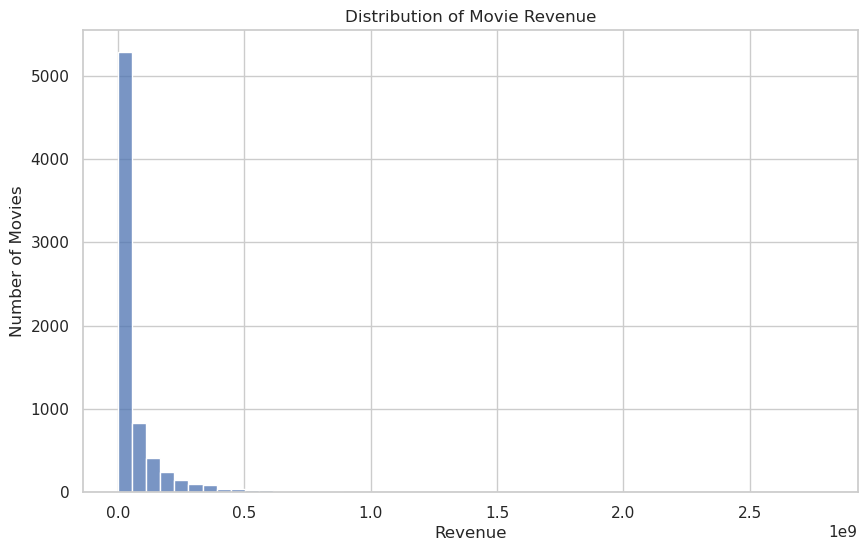

In [71]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=runtime_revenue_data,
    x="revenue",
    bins=50
)

plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")

plt.show()

In [72]:
runtime_revenue_data["revenue"].skew()

np.float64(5.13220881552134)

In [73]:
runtime_revenue_data["revenue"].describe()

count    7.358000e+03
mean     6.919655e+07
std      1.468263e+08
min      1.000000e+00
25%      2.435244e+06
50%      1.698600e+07
75%      6.790707e+07
max      2.787965e+09
Name: revenue, dtype: float64

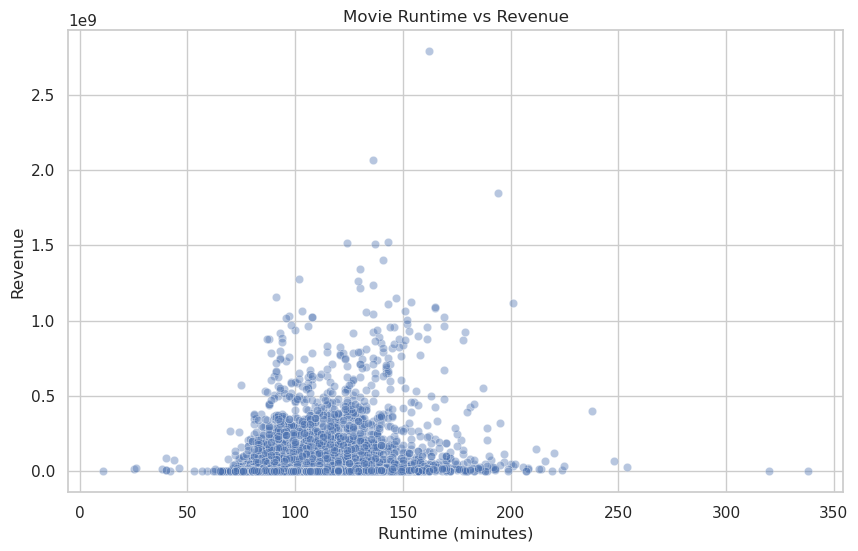

In [74]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=runtime_revenue_data,
    x="runtime",
    y="revenue",
    alpha=0.4
)

plt.title("Movie Runtime vs Revenue")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Revenue")

plt.show()

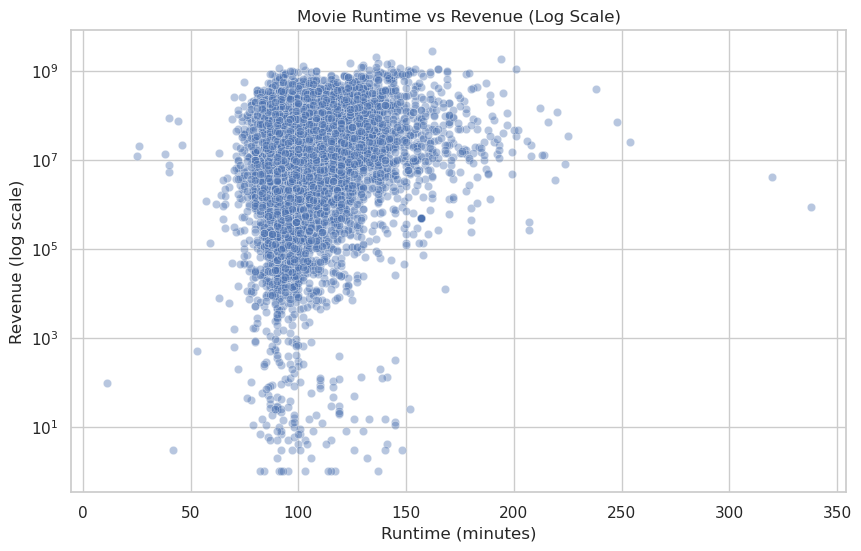

In [75]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=runtime_revenue_data,
    x="runtime",
    y="revenue",
    alpha=0.4
)

plt.yscale("log")

plt.title("Movie Runtime vs Revenue (Log Scale)")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Revenue (log scale)")

plt.show()

In [76]:
runtime_revenue_pearson = (
    runtime_revenue_data["runtime"]
    .corr(runtime_revenue_data["revenue"])
)

runtime_revenue_pearson

np.float64(0.20412728499832913)

In [77]:
runtime_revenue_spearman = (
    runtime_revenue_data["runtime"]
    .corr(
        runtime_revenue_data["revenue"],
        method="spearman"
    )
)

runtime_revenue_spearman

np.float64(0.26314673666853866)

### Findings

Revenue has substantial missingness in the dataset. Only 16.4% of the movies have a recorded revenue value, so this analysis is limited to movies with available revenue and runtime values.

The revenue distribution is highly right-skewed, with a median of approximately 17 million and a maximum of about 2.79 billion. Extreme values were retained because they were not identified as invalid during the data-cleaning stage.

The scatter plot shows a weak positive association between runtime and revenue. The Pearson correlation is 0.204, while the Spearman correlation is 0.263. The higher Spearman correlation suggests that the rank-based relationship is somewhat stronger than the linear relationship.

Overall, runtime alone does not appear to be a strong indicator of movie revenue. The logarithmic scale is used in the scatter plot to make the wide range of revenue values easier to visualize.

## Overall EDA Findings

The exploratory analysis shows that movie runtime is concentrated around the typical range of approximately 80 to 120 minutes, while a smaller number of movies have substantially shorter or longer runtimes.

Runtime varies across genres. Some genres, such as History and War, tend to have higher average runtimes, while Animation and Family tend to have lower average runtimes.

Runtime shows weak positive associations with vote average, popularity, and revenue. The Pearson correlation with vote average is approximately 0.11, while the Pearson correlations with popularity and revenue are approximately 0.11 and 0.20, respectively.

Popularity and revenue are both highly right-skewed, so logarithmic scales were used when appropriate for visualization. Revenue also has substantial missingness, with recorded values available for only about 16.4% of the movies.

Overall, runtime alone does not appear to be a strong indicator of a movie's rating, popularity, or revenue. The analysis suggests that other movie characteristics should be considered alongside runtime when examining movie performance.